# Cuaderno 03: Modelo de Regresión - Predicción de Estancia en UCI

**Objetivo:** Desarrollar, entrenar y evaluar modelos de regresión supervisada capaces de predecir la duración de la estancia de un paciente en la unidad de cuidados intensivos (`DischargeDayNumber`), utilizando las variables demográficas, clínicas y de gravedad disponibles en el momento del ingreso. El pipeline completo se repite sobre dos poblaciones (todos los pacientes y solo los supervivientes) como análisis de sensibilidad, para comprobar si el fallecimiento del paciente distorsiona la estimación de la estancia.

---

## 1. Importación de Librerías
Carga de las herramientas necesarias para la manipulación de datos, la partición, el modelado y la evaluación estadística.

In [2]:
# Importación de librerías base
import pandas as pd
import numpy as np
import os
import warnings

# Estadística para el análisis descriptivo bivariante
from scipy.stats import spearmanr, kruskal, skew

# Herramientas de Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga de Datos y Construcción de las Dos Poblaciones

Se carga el Gold Dataset generado en el Cuaderno 01 y se examina la distribución de la variable objetivo, `DischargeDayNumber` (días de estancia), para justificar las decisiones de modelado. A continuación se construyen las dos poblaciones sobre las que se repite el mismo pipeline completo: todos los pacientes (análisis principal) y solo los supervivientes (análisis de sensibilidad).

### 2.1. Importación de los Datos

In [3]:
print("Cargando el Gold Dataset...")
ruta_parquet = 'datos_procesados/uci_gold_dataset.parquet'

df_uci = pd.read_parquet(ruta_parquet)
print(f"Dimensiones iniciales: {df_uci.shape}\n")

display(df_uci.head())

Cargando el Gold Dataset...
Dimensiones iniciales: (162009, 46)



,Gender,Ethnicity,Age,AdmissionHeight,AdmissionWeight,UnitType,UnitStayType,DiagnosisAdmission,Service,APS,...,PastHistory,Meds,Glucose,Sodium,Creatinine,BUN,Hematocrit,WBC,AdmitHour,DischargeDayNumber
0,Male,Hispanic,54.0,162.6,63.5,CTICU,admit,Unknown,unknown,38.0,...,Unknown/Not Performed,0,174.0,139.0,3.00,30.0,21.6,9.3,Mañana,0
1,Male,Caucasian,69.0,175.0,93.0,SICU,admit,"Renal failure, acute",renal,53.0,...,Performed,0,299.0,134.0,5.04,126.0,30.6,16.5,Noche,0
2,Female,Other/Unknown,72.0,152.4,55.2,Med-Surg ICU,readmit,"Sepsis, other",infectious diseases,56.0,...,Performed,0,41.0,138.0,0.99,19.0,32.6,10.4,Mañana,0
3,Male,Hispanic,66.0,175.3,95.2,Cardiac ICU,admit,"Angina, unstable (angina interferes w/quality ...",cardiovascular,23.0,...,Performed,0,81.0,139.0,1.00,17.0,32.6,10.4,Mañana,0
4,Male,Caucasian,56.0,178.0,86.0,CCU-CTICU,admit,Emphysema/bronchitis,pulmonary,38.0,...,Performed,0,135.0,138.0,0.99,19.0,32.6,10.4,Mañana,0


### 2.2. Distribución de la Variable Objetivo (`DischargeDayNumber`)

La estancia en UCI es, por naturaleza, una variable con **fuerte asimetría a la derecha**. La mayoría de los pacientes permanecen pocos días, mientras que una minoría acumula estancias muy prolongadas (el máximo observado, 506 días, es un caso real y válido de la base de datos de origen, no se elimina como *outlier*). Esta asimetría se comprueba a continuación y motiva el uso de `np.log1p(DischargeDayNumber)` como variable objetivo de entrenamiento en todos los modelos. Entrenar sobre la escala logarítmica evita que los pocos casos extremos dominen la función de pérdida. Al evaluar, la transformación se deshace con `np.expm1()` y todas las métricas finales se reportan en escala original (días).

Estadísticos descriptivos de DischargeDayNumber (días de estancia):
count    162009.00
mean          2.44
std           4.53
min           0.00
25%           0.00
50%           1.00
75%           3.00
max         506.00
Name: DischargeDayNumber, dtype: float64

Asimetría en escala original: 19.67
Asimetría tras log1p:          0.75


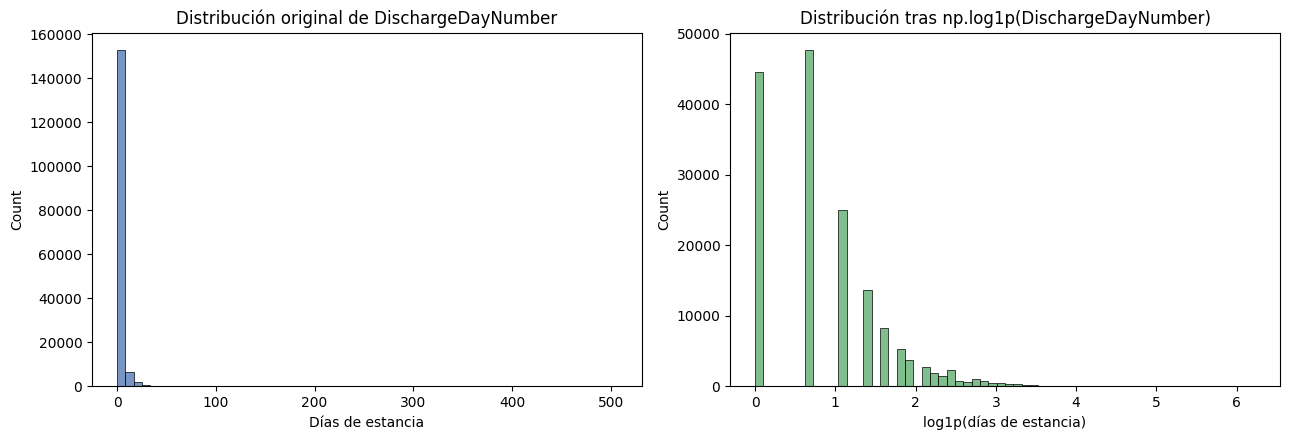

In [4]:
print("Estadísticos descriptivos de DischargeDayNumber (días de estancia):")
print(df_uci['DischargeDayNumber'].describe().round(2))
print(f"\nAsimetría en escala original: {skew(df_uci['DischargeDayNumber']):.2f}")
print(f"Asimetría tras log1p:          {skew(np.log1p(df_uci['DischargeDayNumber'])):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df_uci['DischargeDayNumber'], bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribución original de DischargeDayNumber')
axes[0].set_xlabel('Días de estancia')

sns.histplot(np.log1p(df_uci['DischargeDayNumber']), bins=60, ax=axes[1], color='#55A868')
axes[1].set_title('Distribución tras np.log1p(DischargeDayNumber)')
axes[1].set_xlabel('log1p(días de estancia)')

plt.tight_layout()
plt.show()

### 2.3. Construcción de las Dos Poblaciones

- **Población A - Todos los pacientes:** el dataset completo (162.009 registros). Es el análisis principal.
- **Población B - Solo supervivientes:** se excluyen los registros con `DiedInHospital == 1`. Es un análisis de sensibilidad para comprobar si el fallecimiento (que suele truncar o acortar de forma artificial la estancia que habría tenido el paciente) distorsiona la estimación.

Ambas poblaciones se procesan con el mismo pipeline completo (separación de variables, partición, codificación, análisis descriptivo, modelado y evaluación), encapsulado en funciones reutilizables en la Sección 3 para no duplicar código entre A y B.

In [5]:
df_poblacion_a = df_uci.copy()
df_poblacion_b = df_uci[df_uci['DiedInHospital'] == 0].reset_index(drop=True).copy()

print(f"Población A (todos los pacientes):     {df_poblacion_a.shape[0]} registros")
print(f"Población B (solo supervivientes):     {df_poblacion_b.shape[0]} registros")
print(f"Pacientes excluidos en B (fallecidos): {df_poblacion_a.shape[0] - df_poblacion_b.shape[0]} registros")

Población A (todos los pacientes):     162009 registros
Población B (solo supervivientes):     147208 registros
Pacientes excluidos en B (fallecidos): 14801 registros


## 3. Funciones Reutilizables del Pipeline de Modelado

Población A y Población B se procesan con **exactamente el mismo pipeline**: separación de variables, partición train/test, codificación, análisis descriptivo bivariante, entrenamiento con validación cruzada repetida, selección del modelo ganador y evaluación en test. Encapsular esta lógica en funciones evita duplicar el código entre ambas poblaciones y garantiza que se apliquen los mismos criterios metodológicos a las dos.

### 3.1. Separación de Variables y Partición Train/Test

**Prevención de fugas (modelo de regresión):** se excluyen de las predictoras `DischargeDayNumber` (es el target) y `DiedInHospital`. Esta última se excluye también como predictora porque es un desenlace simultáneo al alta, no información disponible en el momento de predecir la estancia (el modelo es prospectivo, no retrospectivo). El split es 80/20 con `random_state=42`; no se estratifica porque el target ya no es una clase.

In [6]:
def separar_y_dividir(df_poblacion):
    # Separa X (predictoras) e y (target) y realiza el split 80/20 train/test
    target = 'DischargeDayNumber'
    columnas_excluir = [target, 'DiedInHospital']

    X_raw = df_poblacion.drop(columns=columnas_excluir, errors='ignore')
    y = df_poblacion[target]

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y,
        test_size=0.20,
        random_state=42
    )

    # Reseteamos el índice de y para que quede alineado por posición con X_train/X_test
    # tras el One-Hot Encoding, que reconstruye el índice de X mediante pd.concat
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    return X_train_raw, X_test_raw, y_train, y_test

print("Función separar_y_dividir() definida.")

Función separar_y_dividir() definida.


### 3.2. Codificación Categórica (One-Hot Encoding)

Mismo criterio que en el Cuaderno 02: el `OneHotEncoder` se ajusta (`fit`) únicamente con `X_train_raw`, y `X_test_raw` solo se transforma con lo ya aprendido, así ninguna categoría de test influye en la codificación. `drop='first'` evita la trampa de las variables ficticias.

In [7]:
def codificar_onehot(X_train_raw, X_test_raw):
    # Ajusta un OneHotEncoder sobre el train y transforma train y test con él
    cat_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()
    num_cols = [col for col in X_train_raw.columns if col not in cat_cols]

    encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    encoder.fit(X_train_raw[cat_cols])

    train_cat_encoded = encoder.transform(X_train_raw[cat_cols])
    test_cat_encoded = encoder.transform(X_test_raw[cat_cols])
    encoded_cols = encoder.get_feature_names_out(cat_cols)

    X_train = pd.concat([
        X_train_raw[num_cols].reset_index(drop=True),
        pd.DataFrame(train_cat_encoded, columns=encoded_cols)
    ], axis=1)

    X_test = pd.concat([
        X_test_raw[num_cols].reset_index(drop=True),
        pd.DataFrame(test_cat_encoded, columns=encoded_cols)
    ], axis=1)

    return X_train, X_test, encoder

print("Función codificar_onehot() definida.")

Función codificar_onehot() definida.


### 3.3. Análisis Descriptivo Bivariante (Adaptado a Target Continuo)

Análisis puramente descriptivo para la memoria, calculado solo sobre el train de cada población — **no se usa para eliminar variables** del conjunto de modelado (la selección se delega a la regularización L1 de Lasso y a la importancia de variables de los modelos de árboles).

- **Variables continuas** → correlación de **Spearman** con el target (se prioriza sobre Pearson por si la relación no es lineal, dada la asimetría del target).
- **Variables categóricas/binarias** (tras el encoding) → **Kruskal-Wallis** (más robusto que ANOVA cuando el target no sigue una distribución normal, como es el caso).

In [8]:
def analisis_bivariante(X_train, y_train_log):
    # Calcula la asociación de cada predictora con el target (log1p) sobre el train
    vars_binarias = [col for col in X_train.columns if X_train[col].nunique() <= 2]
    vars_continuas = [col for col in X_train.columns if col not in vars_binarias]

    resultados = []

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')

        for col in vars_continuas:
            corr, p_val = spearmanr(X_train[col], y_train_log)
            resultados.append({
                'Variable': col, 'Tipo': 'Continua', 'Test': 'Spearman',
                'Estadistico': corr, 'p-value': p_val
            })

        for col in vars_binarias:
            grupo_0 = y_train_log[X_train[col] == 0]
            grupo_1 = y_train_log[X_train[col] == 1]
            if len(grupo_0) > 0 and len(grupo_1) > 0:
                stat, p_val = kruskal(grupo_0, grupo_1)
            else:
                stat, p_val = np.nan, np.nan
            resultados.append({
                'Variable': col, 'Tipo': 'Binaria', 'Test': 'Kruskal-Wallis',
                'Estadistico': stat, 'p-value': p_val
            })

    df_asociacion = pd.DataFrame(resultados)
    df_asociacion['Asociacion_significativa'] = df_asociacion['p-value'] < 0.05
    df_asociacion = df_asociacion.sort_values(by='p-value').reset_index(drop=True)
    return df_asociacion

print("Función analisis_bivariante() definida.")

Función analisis_bivariante() definida.


### 3.4. Definición de los Modelos

Se comparan tres algoritmos de regresión supervisada:

1. **Lasso** — dentro de un `Pipeline` con `StandardScaler` previo (ajustado solo en train), ya que Lasso es sensible a la escala de las variables. Baseline interpretable con selección de variables embebida (regularización L1).
2. **RandomForestRegressor** — modelo de ensamblado basado en árboles, robusto a relaciones no lineales.
3. **XGBRegressor** — *gradient boosting*, referencia de rendimiento en datos tabulares.

Se define como función (en lugar de un diccionario fijo) para poder crear instancias nuevas y sin entrenar para cada población.

In [9]:
def crear_modelos():
    # Devuelve un diccionario con instancias nuevas (sin entrenar) de los 3 modelos
    return {
        'Lasso': Pipeline([
            ('scaler', StandardScaler()),
            ('lasso', Lasso(random_state=42, max_iter=10000))
        ]),
        'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
        'XGBoost': XGBRegressor(random_state=42, n_jobs=-1)
    }

print("Función crear_modelos() definida.")

Función crear_modelos() definida.


### 3.5. Validación Cruzada Repetida (RMSE y MAE)

Mismo criterio que en el Cuaderno 02, en lugar de una única partición, se emplea validación cruzada **repetida**, 5 particiones (`KFold`) repetidas 3 veces con particiones distintas (`RepeatedKFold`), es decir, cada modelo se entrena y evalúa 15 veces en total. No se estratifica (el target ya no es una clase). Las métricas se calculan **sobre el target transformado (`log1p`)**: **RMSE** es el criterio principal de selección del modelo ganador, y **MAE** se reporta como métrica de apoyo (más robusta frente a los pocos casos extremos).

In [10]:
N_REPEATS = 3
N_SPLITS = 5

def validar_cruzada(modelos, X_train, y_train_log):
    # Ejecuta RepeatedKFold (5x3) sobre los modelos y devuelve resultados agregados y por repetición
    cv_repetida = RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)
    scoring = {
        'RMSE': 'neg_root_mean_squared_error',
        'MAE': 'neg_mean_absolute_error'
    }

    resultados_cv = {}
    resultados_por_repeticion = {}

    for nombre, modelo in modelos.items():
        print(f"  Ejecutando validación cruzada repetida ({N_REPEATS}x{N_SPLITS} = {N_REPEATS * N_SPLITS} entrenamientos): {nombre}...")
        scores = cross_validate(modelo, X_train, y_train_log, cv=cv_repetida, scoring=scoring, n_jobs=1)

        # Los scores 'neg_*' de sklearn se invierten para trabajar con RMSE/MAE en positivo
        rmse_scores = -scores['test_RMSE']
        mae_scores = -scores['test_MAE']

        rmse_por_rep = rmse_scores.reshape(N_REPEATS, N_SPLITS).mean(axis=1)
        mae_por_rep = mae_scores.reshape(N_REPEATS, N_SPLITS).mean(axis=1)

        resultados_por_repeticion[nombre] = {'RMSE': rmse_por_rep, 'MAE': mae_por_rep}
        resultados_cv[nombre] = {
            'RMSE (media)': rmse_scores.mean(), 'RMSE (std)': rmse_scores.std(),
            'MAE (media)': mae_scores.mean(), 'MAE (std)': mae_scores.std(),
        }
        print(f"    RMSE (log1p): {resultados_cv[nombre]['RMSE (media)']:.4f} (+/- {resultados_cv[nombre]['RMSE (std)']:.4f})")
        print(f"    MAE (log1p):  {resultados_cv[nombre]['MAE (media)']:.4f} (+/- {resultados_cv[nombre]['MAE (std)']:.4f})")

    df_comparacion = pd.DataFrame(resultados_cv).T.sort_values(by='RMSE (media)')
    return df_comparacion, resultados_por_repeticion

print("Función validar_cruzada() definida.")

Función validar_cruzada() definida.


### 3.6. Entrenamiento y Evaluación del Modelo Ganador

El modelo con menor RMSE medio en validación cruzada se reentrena sobre la totalidad del train y se evalúa sobre el test correspondiente, deshaciendo la transformación logarítmica (`np.expm1`) para reportar RMSE y MAE en días reales, la escala en la que se interpreta clínicamente el resultado.

In [11]:
def entrenar_y_evaluar_ganador(df_comparacion, modelos, X_train, y_train_log, X_test, y_test):
    # Reentrena el modelo con menor RMSE (CV) sobre todo el train y lo evalúa en test (escala original)
    nombre_ganador = df_comparacion.index[0]
    modelo_ganador = modelos[nombre_ganador]

    print(f"Modelo ganador (menor RMSE en validación cruzada): {nombre_ganador}")
    print("Entrenando el modelo ganador sobre todo el train...")
    modelo_ganador.fit(X_train, y_train_log)

    y_pred_log = modelo_ganador.predict(X_test)

    # Deshacemos la transformación logarítmica para evaluar en días reales
    y_pred_dias = np.expm1(y_pred_log)
    y_pred_dias = np.clip(y_pred_dias, a_min=0, a_max=None)  # la estancia no puede ser negativa

    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_dias))
    mae_test = mean_absolute_error(y_test, y_pred_dias)

    print(f"\nRendimiento en Test (escala original, días):")
    print(f"RMSE: {rmse_test:.4f}")
    print(f"MAE:  {mae_test:.4f}")

    return nombre_ganador, modelo_ganador, y_pred_dias, rmse_test, mae_test

print("Función entrenar_y_evaluar_ganador() definida.")

Función entrenar_y_evaluar_ganador() definida.


### 3.7. Importancia de Variables del Modelo Ganador

Se extrae el ranking de variables más relevantes del modelo ganador, valor absoluto de `coef_` si es Lasso, o `feature_importances_` si es Random Forest o XGBoost. Este ranking se usa en la Sección 6 para comparar si las variables relevantes cambian entre la Población A y la Población B.

In [12]:
def obtener_importancia_variables(nombre_modelo, modelo, columnas):
    # Devuelve una Serie con la importancia de cada variable, ordenada de mayor a menor
    if nombre_modelo == 'Lasso':
        importancias = np.abs(modelo.named_steps['lasso'].coef_)
    else:
        importancias = modelo.feature_importances_

    return pd.Series(importancias, index=columnas).sort_values(ascending=False)

print("Función obtener_importancia_variables() definida.")

Función obtener_importancia_variables() definida.


## 4. Población A - Todos los Pacientes (Análisis Principal)

Se aplica el pipeline completo definido en la Sección 3 sobre la totalidad del dataset (162.009 registros).

### 4.1. Separación, Partición y Codificación

In [13]:
print("=== POBLACIÓN A -- Todos los pacientes ===\n")

X_train_raw_a, X_test_raw_a, y_train_a, y_test_a = separar_y_dividir(df_poblacion_a)
print(f"Filas para Entrenamiento (Train): {X_train_raw_a.shape[0]}")
print(f"Filas para Validación (Test): {X_test_raw_a.shape[0]}")

X_train_a, X_test_a, encoder_a = codificar_onehot(X_train_raw_a, X_test_raw_a)
print(f"\nDimensiones de X_train tras el encoding: {X_train_a.shape}")
print(f"Dimensiones de X_test tras el encoding: {X_test_a.shape}")

# Transformación logarítmica del target de entrenamiento
# (y_test_a se mantiene en escala original para la evaluación final en días)
y_train_a_log = np.log1p(y_train_a)

display(X_train_a.head())

=== POBLACIÓN A -- Todos los pacientes ===

Filas para Entrenamiento (Train): 129607
Filas para Validación (Test): 32402

Dimensiones de X_train tras el encoding: (129607, 141)
Dimensiones de X_test tras el encoding: (32402, 141)


,Age,AdmissionHeight,AdmissionWeight,APS,ApacheScore,HeartRate_Admission,MeanBP_Admission,Temperature,RespiratoryRate_Admission,Intubated,...,Service_pulmonary,Service_renal,Service_surgery,Service_toxicology,Service_transplant,Service_unknown,PastHistory_Performed,PastHistory_Unknown/Not Performed,AdmitHour_Noche,AdmitHour_Tarde
0,59.0,172.7,90.4,47.0,52.0,128.0,119.0,36.29,29.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,70.0,180.3,101.3,25.0,41.0,96.0,135.0,36.60,39.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,75.0,152.0,88.0,57.0,74.0,110.0,40.0,35.10,10.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,81.0,149.8,68.1,17.0,34.0,60.0,76.0,36.29,46.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,89.0,203.2,115.9,46.0,81.0,102.0,57.0,36.39,25.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### 4.2. Análisis Descriptivo Bivariante (Train, Población A)

In [14]:
print("Calculando asociación bivariante de cada predictora con el target (log1p)...")
df_asociacion_a = analisis_bivariante(X_train_a, y_train_a_log)

print(f"\nTotal de variables analizadas: {len(df_asociacion_a)}")
print(f"Variables con asociación estadísticamente significativa (p<0.05): {df_asociacion_a['Asociacion_significativa'].sum()}")
print(f"Variables sin asociación estadística significativa: {(~df_asociacion_a['Asociacion_significativa']).sum()}")
print("\nNota: esta tabla es informativa. Todas las variables se mantienen en X_train/X_test")
print("para el entrenamiento; la selección final se delega a cada algoritmo.\n")

def resaltar_significancia(val):
    if isinstance(val, bool):
        color = '#4CAF50' if val else '#F44336'
        return f'background-color: {color}; color: white; font-weight: bold'
    return ''

display(df_asociacion_a.style.map(resaltar_significancia, subset=['Asociacion_significativa'])
                  .format({'Estadistico': '{:.4f}', 'p-value': '{:.4e}'}))

Calculando asociación bivariante de cada predictora con el target (log1p)...

Total de variables analizadas: 141
Variables con asociación estadísticamente significativa (p<0.05): 123
Variables sin asociación estadística significativa: 18

Nota: esta tabla es informativa. Todas las variables se mantienen en X_train/X_test
para el entrenamiento; la selección final se delega a cada algoritmo.



,Variable,Tipo,Test,Estadistico,p-value,Asociacion_significativa
0,APS,Continua,Spearman,0.3108,0.0000e+00,True
1,ApacheScore,Continua,Spearman,0.2983,0.0000e+00,True
2,HeartRate_Admission,Continua,Spearman,0.1583,0.0000e+00,True
3,Eyes,Continua,Spearman,-0.2009,0.0000e+00,True
4,BUN,Continua,Spearman,0.1410,0.0000e+00,True
5,Verbal,Continua,Spearman,-0.2415,0.0000e+00,True
6,Motor,Continua,Spearman,-0.2012,0.0000e+00,True
7,Hematocrit,Continua,Spearman,-0.1110,0.0000e+00,True
8,ActiveTreatment,Binaria,Kruskal-Wallis,9929.6080,0.0000e+00,True
9,Vent,Binaria,Kruskal-Wallis,9993.7485,0.0000e+00,True


### 4.3. Entrenamiento y Validación Cruzada Repetida de los 3 Modelos

In [15]:
print("Definiendo modelos para la Población A...")
modelos_a = crear_modelos()

print("\nEjecutando validación cruzada repetida...\n")
df_comparacion_a, resultados_por_rep_a = validar_cruzada(modelos_a, X_train_a, y_train_a_log)

print("\nTabla comparativa (ordenada por RMSE medio, criterio principal):")
display(df_comparacion_a.style.format('{:.4f}').background_gradient(cmap='Greens_r', subset=['RMSE (media)', 'MAE (media)']))

Definiendo modelos para la Población A...

Ejecutando validación cruzada repetida...

  Ejecutando validación cruzada repetida (3x5 = 15 entrenamientos): Lasso...
    RMSE (log1p): 0.7557 (+/- 0.0039)
    MAE (log1p):  0.6036 (+/- 0.0024)
  Ejecutando validación cruzada repetida (3x5 = 15 entrenamientos): Random Forest...
    RMSE (log1p): 0.6558 (+/- 0.0036)
    MAE (log1p):  0.5115 (+/- 0.0025)
  Ejecutando validación cruzada repetida (3x5 = 15 entrenamientos): XGBoost...
    RMSE (log1p): 0.6497 (+/- 0.0035)
    MAE (log1p):  0.5069 (+/- 0.0027)

Tabla comparativa (ordenada por RMSE medio, criterio principal):


,RMSE (media),RMSE (std),MAE (media),MAE (std)
XGBoost,0.6497,0.0035,0.5069,0.0027
Random Forest,0.6558,0.0036,0.5115,0.0025
Lasso,0.7557,0.0039,0.6036,0.0024


### 4.3.1. Tabla de Resultados por Repetición (Población A)

Detalle de las 3 ejecuciones independientes (cada una promedio de sus 5 folds), para documentar la variabilidad del resultado antes de resumirlo en una media.

In [16]:
filas_a = []
for rep in range(N_REPEATS):
    fila = {'Repetición': rep + 1}
    for nombre in modelos_a:
        fila[f'{nombre} - RMSE'] = resultados_por_rep_a[nombre]['RMSE'][rep]
        fila[f'{nombre} - MAE'] = resultados_por_rep_a[nombre]['MAE'][rep]
    filas_a.append(fila)

df_repeticiones_a = pd.DataFrame(filas_a).set_index('Repetición')
df_repeticiones_a.loc['Media'] = df_repeticiones_a.mean()
df_repeticiones_a.loc['Desv. Típica'] = df_repeticiones_a.loc[
    [i for i in df_repeticiones_a.index if i not in ('Media', 'Desv. Típica')]
].std()

display(df_repeticiones_a.style.format('{:.4f}'))

,Lasso - RMSE,Lasso - MAE,Random Forest - RMSE,Random Forest - MAE,XGBoost - RMSE,XGBoost - MAE
Repetición,,,,,,
1,0.7557,0.6036,0.6560,0.5117,0.6498,0.5070
2,0.7557,0.6036,0.6556,0.5114,0.6501,0.5071
3,0.7557,0.6036,0.6557,0.5115,0.6493,0.5065
Media,0.7557,0.6036,0.6558,0.5115,0.6497,0.5069
Desv. Típica,0.0000,0.0000,0.0002,0.0002,0.0004,0.0003


### 4.4. Selección y Evaluación del Modelo Ganador en Test

In [17]:
nombre_ganador_a, modelo_ganador_a, y_pred_test_a, rmse_test_a, mae_test_a = entrenar_y_evaluar_ganador(
    df_comparacion_a, modelos_a, X_train_a, y_train_a_log, X_test_a, y_test_a
)

Modelo ganador (menor RMSE en validación cruzada): XGBoost
Entrenando el modelo ganador sobre todo el train...

Rendimiento en Test (escala original, días):
RMSE: 3.7814
MAE:  1.7974


### 4.5. Análisis de Residuos (Población A)

El análisis de residuos se realiza únicamente sobre la Población A (análisis principal), en escala original (días), para comprobar si el error del modelo crece de forma sistemática en las estancias más largas.

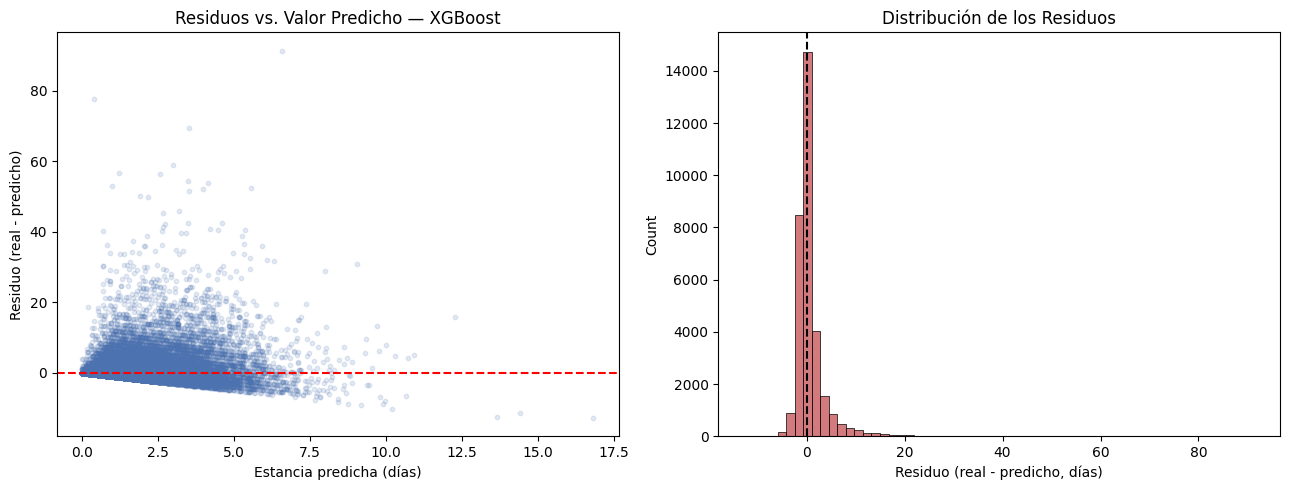

Residuo medio: 0.7828 días
Desviación típica de los residuos: 3.6995 días


In [18]:
residuos_a = y_test_a.values - y_pred_test_a

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_test_a, residuos_a, alpha=0.15, s=10, color='#4C72B0')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Estancia predicha (días)')
axes[0].set_ylabel('Residuo (real - predicho)')
axes[0].set_title(f'Residuos vs. Valor Predicho — {nombre_ganador_a}')

sns.histplot(residuos_a, bins=60, ax=axes[1], color='#C44E52')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residuo (real - predicho, días)')
axes[1].set_title('Distribución de los Residuos')

plt.tight_layout()
plt.show()

print(f"Residuo medio: {residuos_a.mean():.4f} días")
print(f"Desviación típica de los residuos: {residuos_a.std():.4f} días")

### 4.6. Importancia de Variables (Población A)

Top 15 variables más importantes -- XGBoost (Población A):


,Importancia
IntubApacheDay,0.318855
VentApacheDay,0.048769
ActiveTreatment,0.024966
"DiagnosisAdmission_CABG alone, coronary artery bypass grafting",0.019310
Vent,0.019268
Service_toxicology,0.018804
"DiagnosisAdmission_Endarterectomy, carotid",0.018672
DiagnosisAdmission_Unknown,0.018245
Service_neurologic,0.017972
APS,0.016349


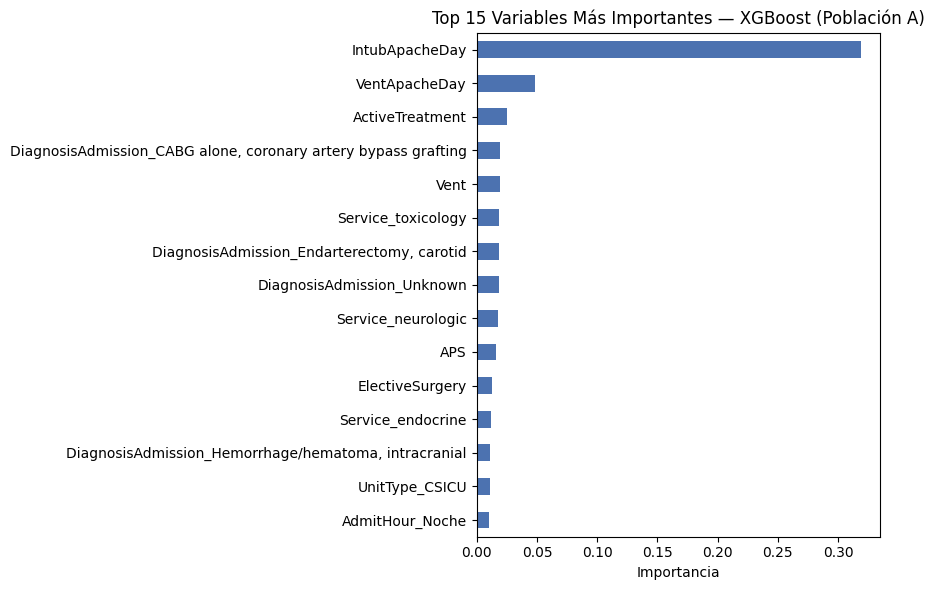

In [19]:
importancia_a = obtener_importancia_variables(nombre_ganador_a, modelo_ganador_a, X_train_a.columns)

print(f"Top 15 variables más importantes -- {nombre_ganador_a} (Población A):")
display(importancia_a.head(15).to_frame('Importancia').style.background_gradient(cmap='Blues'))

fig, ax = plt.subplots(figsize=(9, 6))
importancia_a.head(15).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title(f'Top 15 Variables Más Importantes — {nombre_ganador_a} (Población A)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

## 5. Población B - Solo Supervivientes (Análisis de Sensibilidad)

Se repite exactamente el mismo pipeline de la Sección 4 (mismas funciones reutilizables de la Sección 3), esta vez excluyendo a los pacientes fallecidos, para comprobar si el fallecimiento distorsiona la estimación de la estancia.

### 5.1. Separación, Partición y Codificación

In [20]:
print("=== POBLACIÓN B -- Solo supervivientes ===\n")

X_train_raw_b, X_test_raw_b, y_train_b, y_test_b = separar_y_dividir(df_poblacion_b)
print(f"Filas para Entrenamiento (Train): {X_train_raw_b.shape[0]}")
print(f"Filas para Validación (Test): {X_test_raw_b.shape[0]}")

X_train_b, X_test_b, encoder_b = codificar_onehot(X_train_raw_b, X_test_raw_b)
print(f"\nDimensiones de X_train tras el encoding: {X_train_b.shape}")
print(f"Dimensiones de X_test tras el encoding: {X_test_b.shape}")

y_train_b_log = np.log1p(y_train_b)

display(X_train_b.head())

=== POBLACIÓN B -- Solo supervivientes ===

Filas para Entrenamiento (Train): 117766
Filas para Validación (Test): 29442

Dimensiones de X_train tras el encoding: (117766, 141)
Dimensiones de X_test tras el encoding: (29442, 141)


,Age,AdmissionHeight,AdmissionWeight,APS,ApacheScore,HeartRate_Admission,MeanBP_Admission,Temperature,RespiratoryRate_Admission,Intubated,...,Service_pulmonary,Service_renal,Service_surgery,Service_toxicology,Service_transplant,Service_unknown,PastHistory_Performed,PastHistory_Unknown/Not Performed,AdmitHour_Noche,AdmitHour_Tarde
0,79.0,177.0,89.20,38.0,51.0,60.0,48.0,36.20,4.0,1,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,59.0,188.0,73.00,25.0,30.0,94.0,54.0,35.60,11.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,77.0,147.0,76.20,38.0,51.0,106.0,46.0,36.70,26.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,70.0,175.3,83.91,48.0,64.0,126.0,147.0,37.39,34.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,90.0,172.7,79.60,47.0,71.0,84.0,52.0,36.39,4.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


### 5.2. Análisis Descriptivo Bivariante (Train, Población B)

In [21]:
print("Calculando asociación bivariante de cada predictora con el target (log1p)...")
df_asociacion_b = analisis_bivariante(X_train_b, y_train_b_log)

print(f"\nTotal de variables analizadas: {len(df_asociacion_b)}")
print(f"Variables con asociación estadísticamente significativa (p<0.05): {df_asociacion_b['Asociacion_significativa'].sum()}")
print(f"Variables sin asociación estadística significativa: {(~df_asociacion_b['Asociacion_significativa']).sum()}")
print("\nNota: esta tabla es informativa. Todas las variables se mantienen en X_train/X_test")
print("para el entrenamiento; la selección final se delega a cada algoritmo.\n")

display(df_asociacion_b.style.map(resaltar_significancia, subset=['Asociacion_significativa'])
                  .format({'Estadistico': '{:.4f}', 'p-value': '{:.4e}'}))

Calculando asociación bivariante de cada predictora con el target (log1p)...

Total de variables analizadas: 141
Variables con asociación estadísticamente significativa (p<0.05): 121
Variables sin asociación estadística significativa: 20

Nota: esta tabla es informativa. Todas las variables se mantienen en X_train/X_test
para el entrenamiento; la selección final se delega a cada algoritmo.



,Variable,Tipo,Test,Estadistico,p-value,Asociacion_significativa
0,APS,Continua,Spearman,0.3200,0.0000e+00,True
1,ApacheScore,Continua,Spearman,0.3079,0.0000e+00,True
2,HeartRate_Admission,Continua,Spearman,0.1689,0.0000e+00,True
3,Eyes,Continua,Spearman,-0.2208,0.0000e+00,True
4,BUN,Continua,Spearman,0.1361,0.0000e+00,True
5,Verbal,Continua,Spearman,-0.2613,0.0000e+00,True
6,Motor,Continua,Spearman,-0.2279,0.0000e+00,True
7,Hematocrit,Continua,Spearman,-0.1118,0.0000e+00,True
8,ActiveTreatment,Binaria,Kruskal-Wallis,9518.9581,0.0000e+00,True
9,Vent,Binaria,Kruskal-Wallis,10418.3980,0.0000e+00,True


### 5.3. Entrenamiento y Validación Cruzada Repetida de los 3 Modelos

In [22]:
print("Definiendo modelos para la Población B...")
modelos_b = crear_modelos()

print("\nEjecutando validación cruzada repetida...\n")
df_comparacion_b, resultados_por_rep_b = validar_cruzada(modelos_b, X_train_b, y_train_b_log)

print("\nTabla comparativa (ordenada por RMSE medio, criterio principal):")
display(df_comparacion_b.style.format('{:.4f}').background_gradient(cmap='Greens_r', subset=['RMSE (media)', 'MAE (media)']))

Definiendo modelos para la Población B...

Ejecutando validación cruzada repetida...

  Ejecutando validación cruzada repetida (3x5 = 15 entrenamientos): Lasso...
    RMSE (log1p): 0.7357 (+/- 0.0038)
    MAE (log1p):  0.5839 (+/- 0.0031)
  Ejecutando validación cruzada repetida (3x5 = 15 entrenamientos): Random Forest...
    RMSE (log1p): 0.6287 (+/- 0.0036)
    MAE (log1p):  0.4900 (+/- 0.0028)
  Ejecutando validación cruzada repetida (3x5 = 15 entrenamientos): XGBoost...
    RMSE (log1p): 0.6225 (+/- 0.0041)
    MAE (log1p):  0.4856 (+/- 0.0028)

Tabla comparativa (ordenada por RMSE medio, criterio principal):


,RMSE (media),RMSE (std),MAE (media),MAE (std)
XGBoost,0.6225,0.0041,0.4856,0.0028
Random Forest,0.6287,0.0036,0.4900,0.0028
Lasso,0.7357,0.0038,0.5839,0.0031


### 5.3.1. Tabla de Resultados por Repetición (Población B)

In [23]:
filas_b = []
for rep in range(N_REPEATS):
    fila = {'Repetición': rep + 1}
    for nombre in modelos_b:
        fila[f'{nombre} — RMSE'] = resultados_por_rep_b[nombre]['RMSE'][rep]
        fila[f'{nombre} — MAE'] = resultados_por_rep_b[nombre]['MAE'][rep]
    filas_b.append(fila)

df_repeticiones_b = pd.DataFrame(filas_b).set_index('Repetición')
df_repeticiones_b.loc['Media'] = df_repeticiones_b.mean()
df_repeticiones_b.loc['Desv. Típica'] = df_repeticiones_b.loc[
    [i for i in df_repeticiones_b.index if i not in ('Media', 'Desv. Típica')]
].std()

display(df_repeticiones_b.style.format('{:.4f}'))

,Lasso — RMSE,Lasso — MAE,Random Forest — RMSE,Random Forest — MAE,XGBoost — RMSE,XGBoost — MAE
Repetición,,,,,,
1,0.7357,0.5839,0.6289,0.4902,0.6224,0.4855
2,0.7357,0.5839,0.6285,0.4899,0.6225,0.4856
3,0.7357,0.5839,0.6288,0.4899,0.6226,0.4857
Media,0.7357,0.5839,0.6287,0.4900,0.6225,0.4856
Desv. Típica,0.0000,0.0000,0.0002,0.0002,0.0001,0.0001


### 5.4. Selección y Evaluación del Modelo Ganador en Test

In [24]:
nombre_ganador_b, modelo_ganador_b, y_pred_test_b, rmse_test_b, mae_test_b = entrenar_y_evaluar_ganador(
    df_comparacion_b, modelos_b, X_train_b, y_train_b_log, X_test_b, y_test_b
)

Modelo ganador (menor RMSE en validación cruzada): XGBoost
Entrenando el modelo ganador sobre todo el train...

Rendimiento en Test (escala original, días):
RMSE: 4.5424
MAE:  1.6601


### 5.5. Importancia de Variables (Población B)

Top 15 variables más importantes -- XGBoost (Población B):


,Importancia
IntubApacheDay,0.422668
VentApacheDay,0.043128
Service_toxicology,0.025820
ElectiveSurgery,0.021210
ActiveTreatment,0.018744
DiagnosisAdmission_Unknown,0.017447
APS,0.015136
Service_neurologic,0.012953
Service_endocrine,0.012866
Vent,0.012675


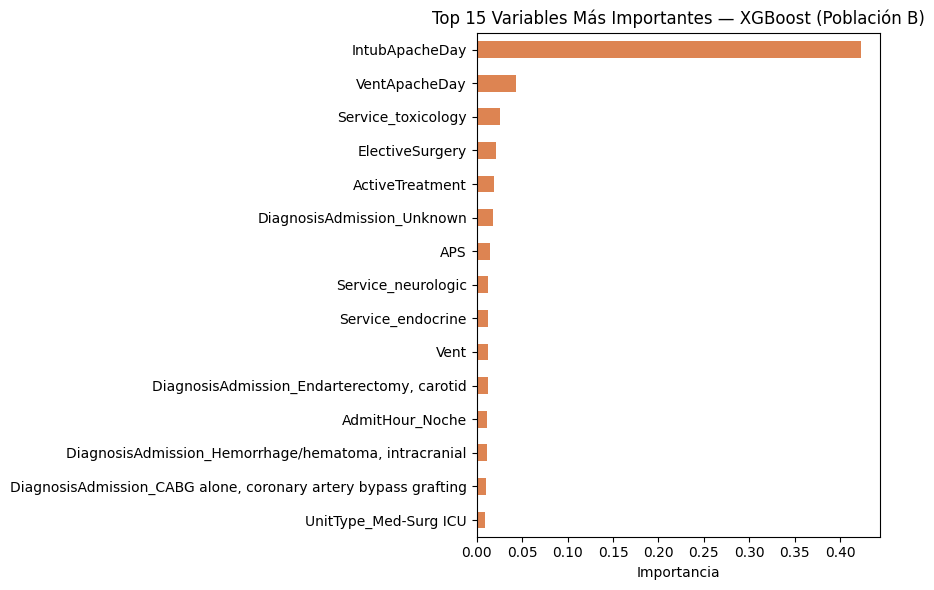

In [25]:
importancia_b = obtener_importancia_variables(nombre_ganador_b, modelo_ganador_b, X_train_b.columns)

print(f"Top 15 variables más importantes -- {nombre_ganador_b} (Población B):")
display(importancia_b.head(15).to_frame('Importancia').style.background_gradient(cmap='Oranges'))

fig, ax = plt.subplots(figsize=(9, 6))
importancia_b.head(15).sort_values().plot(kind='barh', ax=ax, color='#DD8452')
ax.set_title(f'Top 15 Variables Más Importantes — {nombre_ganador_b} (Población B)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

## 6. Comparación Final: Población A vs. Población B

### 6.1. Comparación de Métricas

Se comparan las métricas obtenidas en test (escala original, días) por el modelo ganador de cada población.

In [26]:
df_comparacion_final = pd.DataFrame({
    'Población A (Todos)': {
        'Modelo ganador': nombre_ganador_a,
        'RMSE (días)': rmse_test_a,
        'MAE (días)': mae_test_a,
    },
    'Población B (Supervivientes)': {
        'Modelo ganador': nombre_ganador_b,
        'RMSE (días)': rmse_test_b,
        'MAE (días)': mae_test_b,
    },
}).T

display(df_comparacion_final)

print(f"\nDiferencia relativa de RMSE (B vs. A): {(rmse_test_b - rmse_test_a) / rmse_test_a * 100:+.2f}%")
print(f"Diferencia relativa de MAE (B vs. A):  {(mae_test_b - mae_test_a) / mae_test_a * 100:+.2f}%")

,Modelo ganador,RMSE (días),MAE (días)
Población A (Todos),XGBoost,3.781445,1.797423
Población B (Supervivientes),XGBoost,4.542399,1.660123



Diferencia relativa de RMSE (B vs. A): +20.12%
Diferencia relativa de MAE (B vs. A):  -7.64%


### 6.2. Comparación del Ranking de Variables Importantes

Se comparan las 15 variables más importantes de cada población. **Nota de interpretación:** si el modelo ganador difiere entre A y B, la magnitud de "importancia" no es directamente comparable entre ambos (los coeficientes de Lasso, la impureza media de Random Forest y la ganancia de XGBoost tienen escalas distintas), lo que sí es comparable y relevante para la discusión es **qué variables aparecen** en el top y **su posición relativa (rank)** dentro de cada población.

,Rank Población A,Rank Población B
IntubApacheDay,1,1
VentApacheDay,2,2
ActiveTreatment,3,5
"DiagnosisAdmission_CABG alone, coronary artery bypass grafting",4,14
Vent,5,10
Service_toxicology,6,3
"DiagnosisAdmission_Endarterectomy, carotid",7,11
DiagnosisAdmission_Unknown,8,6
Service_neurologic,9,8
APS,10,7


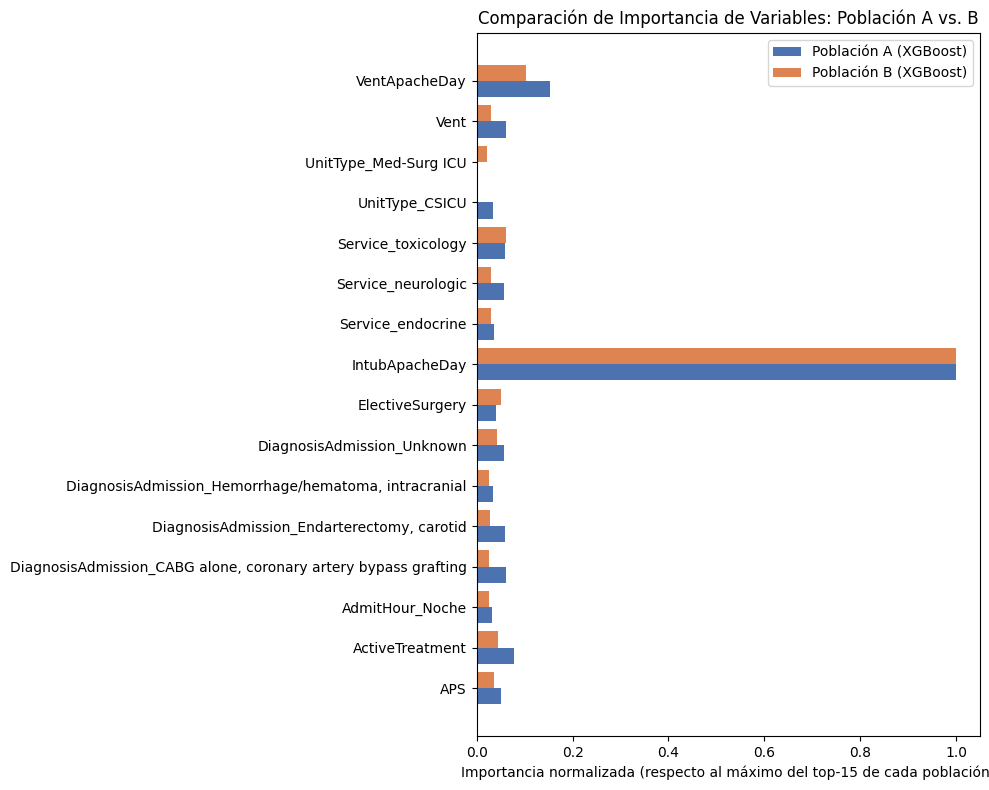

In [27]:
top_a = importancia_a.head(15)
top_b = importancia_b.head(15)

variables_union = sorted(set(top_a.index) | set(top_b.index))

rank_a_completo = pd.Series(range(1, len(importancia_a) + 1), index=importancia_a.index)
rank_b_completo = pd.Series(range(1, len(importancia_b) + 1), index=importancia_b.index)

df_ranking_comparado = pd.DataFrame({
    'Rank Población A': rank_a_completo,
    'Rank Población B': rank_b_completo,
}).loc[variables_union].sort_values(by='Rank Población A')

display(df_ranking_comparado)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(variables_union))
importancias_a_norm = top_a / top_a.max()
importancias_b_norm = top_b / top_b.max()

ax.barh(y_pos - 0.2, [importancias_a_norm.get(v, 0) for v in variables_union], height=0.4,
        label=f'Población A ({nombre_ganador_a})', color='#4C72B0')
ax.barh(y_pos + 0.2, [importancias_b_norm.get(v, 0) for v in variables_union], height=0.4,
        label=f'Población B ({nombre_ganador_b})', color='#DD8452')
ax.set_yticks(y_pos)
ax.set_yticklabels(variables_union)
ax.set_xlabel('Importancia normalizada (respecto al máximo del top-15 de cada población)')
ax.set_title('Comparación de Importancia de Variables: Población A vs. B')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Exportación para el dashboard: resultados de regresión (Poblaciones A y B)

In [28]:
import os

os.makedirs('../data', exist_ok=True)

cols_filtro = ['Age', 'Gender', 'Ethnicity', 'UnitType', 'Service']

df_export_a = X_test_raw_a.reset_index(drop=True)[cols_filtro].copy()
df_export_a['Poblacion'] = 'A'
df_export_a['y_true_dias'] = y_test_a
df_export_a['y_pred_dias'] = y_pred_test_a

df_export_b = X_test_raw_b.reset_index(drop=True)[cols_filtro].copy()
df_export_b['Poblacion'] = 'B'
df_export_b['y_true_dias'] = y_test_b
df_export_b['y_pred_dias'] = y_pred_test_b

df_export_estancia = pd.concat([df_export_a, df_export_b], ignore_index=True)
df_export_estancia.to_parquet('../data/estancia_resultados.parquet', index=False)
print(f"Exportado data/estancia_resultados.parquet -- {df_export_estancia.shape}")
print(df_export_estancia['Poblacion'].value_counts())

Exportado data/estancia_resultados.parquet -- (61844, 8)
Poblacion
A    32402
B    29442
Name: count, dtype: int64


In [29]:
df_importancia_a = importancia_a.reset_index()
df_importancia_a.columns = ['Variable', 'Importancia']
df_importancia_a['Poblacion'] = 'A'
df_importancia_a['ModeloGanador'] = nombre_ganador_a

df_importancia_b = importancia_b.reset_index()
df_importancia_b.columns = ['Variable', 'Importancia']
df_importancia_b['Poblacion'] = 'B'
df_importancia_b['ModeloGanador'] = nombre_ganador_b

df_export_importancia = pd.concat([df_importancia_a, df_importancia_b], ignore_index=True)
df_export_importancia.to_parquet('../data/estancia_importancia.parquet', index=False)
print(f"Exportado data/estancia_importancia.parquet -- {df_export_importancia.shape}")

Exportado data/estancia_importancia.parquet -- (282, 4)
